In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

PATH = r'C:\Users\Никита\Skillfactory\Project workshop (hackathon)\df_target.csv'
df = pd.read_csv(PATH, low_memory=False)
print('Размер датасета:', df.shape)
df.head(3)

Размер датасета: (1860042, 19)


,session_id,client_id,visit_date,visit_time,visit_number,utm_source,utm_medium,utm_campaign,utm_adcontent,utm_keyword,device_category,device_os,device_brand,device_model,device_screen_resolution,device_browser,geo_country,geo_city,target
0,9055434745589932991.1637753792.1637753792,2108382700.1637753791,2021-11-24,14:36:32,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,NaN,360x720,Chrome,Russia,Zlatoust,0
1,905544597018549464.1636867290.1636867290,210838531.1636867288,2021-11-14,08:21:30,1,MvfHsxITijuriZxsqZqt,cpm,FTjNLDyTrXaWYgZymFkV,xhoenQgDQsgfEPYNPwKO,IGUCNvHlhfHpROGclCit,mobile,Android,Samsung,NaN,385x854,Samsung Internet,Russia,Moscow,0
2,9055446045651783499.1640648526.1640648526,2108385331.1640648523,2021-12-28,02:42:06,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,NaN,360x720,Chrome,Russia,Krasnoyarsk,0


In [2]:
# Типы данных и пропуски
info = pd.DataFrame({
    'dtype': df.dtypes,
    'nulls': df.isnull().sum(),
    'null_%': (df.isnull().sum() / len(df) * 100).round(2),
    'unique': df.nunique()
})
print(info)

                           dtype    nulls  null_%   unique
session_id                object        0    0.00  1860042
client_id                 object        0    0.00  1391719
visit_date                object        0    0.00      226
visit_time                object        0    0.00    85318
visit_number               int64        0    0.00      537
utm_source                object       97    0.01      293
utm_medium                object        0    0.00       56
utm_campaign              object   219603   11.81      412
utm_adcontent             object   335615   18.04      286
utm_keyword               object  1082061   58.17     1219
device_category           object        0    0.00        3
device_os                 object  1070138   57.53       13
device_brand              object   367178   19.74      205
device_model              object  1843704   99.12      104
device_screen_resolution  object        0    0.00     5039
device_browser            object        0    0.00       

Распределение целевой переменной:
target
0    1843320
1      16722
Name: count, dtype: int64

Доля целевых сессий: 0.90%


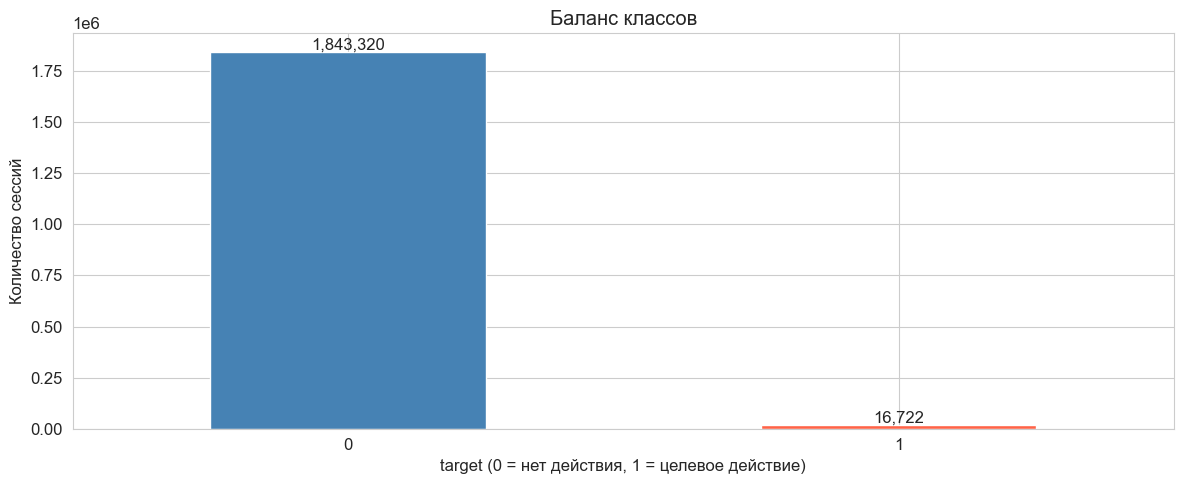

In [3]:
# Баланс классов
print('Распределение целевой переменной:')
print(df['target'].value_counts())
print(f"\nДоля целевых сессий: {df['target'].mean()*100:.2f}%")

fig, ax = plt.subplots()
df['target'].value_counts().plot(kind='bar', ax=ax, color=['steelblue', 'tomato'])
ax.set_title('Баланс классов')
ax.set_xlabel('target (0 = нет действия, 1 = целевое действие)')
ax.set_ylabel('Количество сессий')
ax.set_xticklabels(['0', '1'], rotation=0)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')
plt.tight_layout()
plt.show()

In [4]:
# Приведение типов и базовая очистка
df['visit_date'] = pd.to_datetime(df['visit_date'])
df['visit_number'] = pd.to_numeric(df['visit_number'], errors='coerce')

# Заполняем пропуски в категориальных столбцах
cat_cols = ['utm_source', 'utm_medium', 'utm_campaign', 'utm_keyword',
            'device_os', 'device_brand', 'device_model']
for col in cat_cols:
    df[col] = df[col].fillna('unknown')

# Удаляем почти пустой столбец device_model (99% пропусков)
df.drop(columns=['device_model'], inplace=True)
# Дубликаты
dups = df.duplicated(subset='session_id').sum()
print(f'Дубликатов по session_id: {dups}')
if dups > 0:
    df.drop_duplicates(subset='session_id', inplace=True)

print(f'Датасет после очистки: {df.shape}')

Дубликатов по session_id: 0
Датасет после очистки: (1860042, 18)


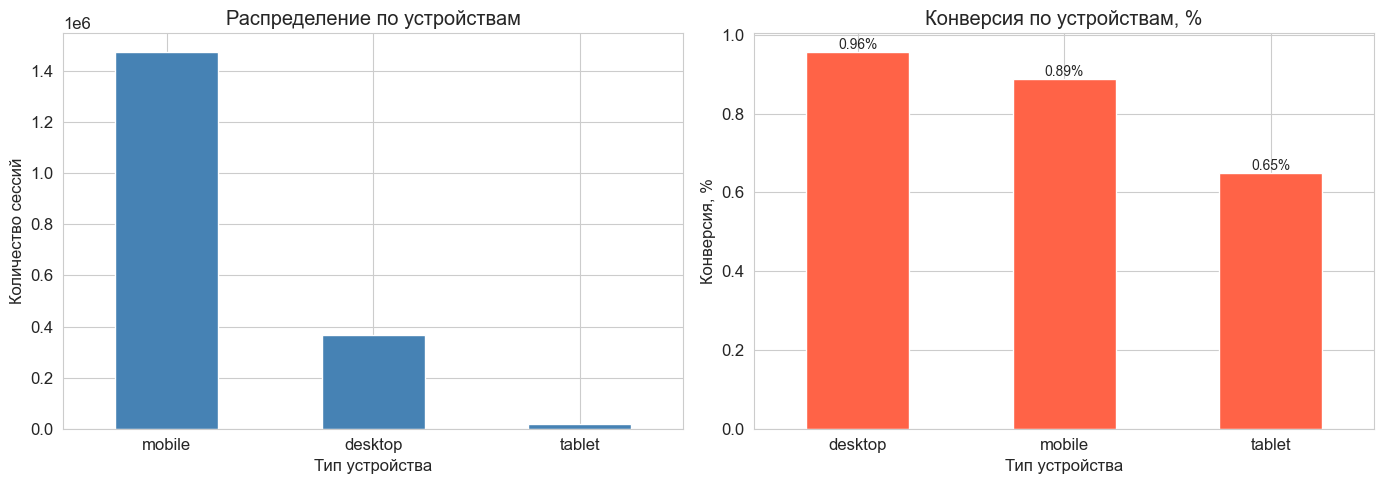


Вывод: десктоп конвертирует лучше, чем мобильные устройства


In [5]:
# Распределение по типам устройств
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

device_counts = df['device_category'].value_counts()
device_counts.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Распределение по устройствам')
axes[0].set_xlabel('Тип устройства')
axes[0].set_ylabel('Количество сессий')
axes[0].tick_params(axis='x', rotation=0)

conv_by_device = df.groupby('device_category')['target'].mean() * 100
conv_by_device.plot(kind='bar', ax=axes[1], color='tomato')
axes[1].set_title('Конверсия по устройствам, %')
axes[1].set_xlabel('Тип устройства')
axes[1].set_ylabel('Конверсия, %')
axes[1].tick_params(axis='x', rotation=0)
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

print('\nВывод: десктоп конвертирует лучше, чем мобильные устройства')

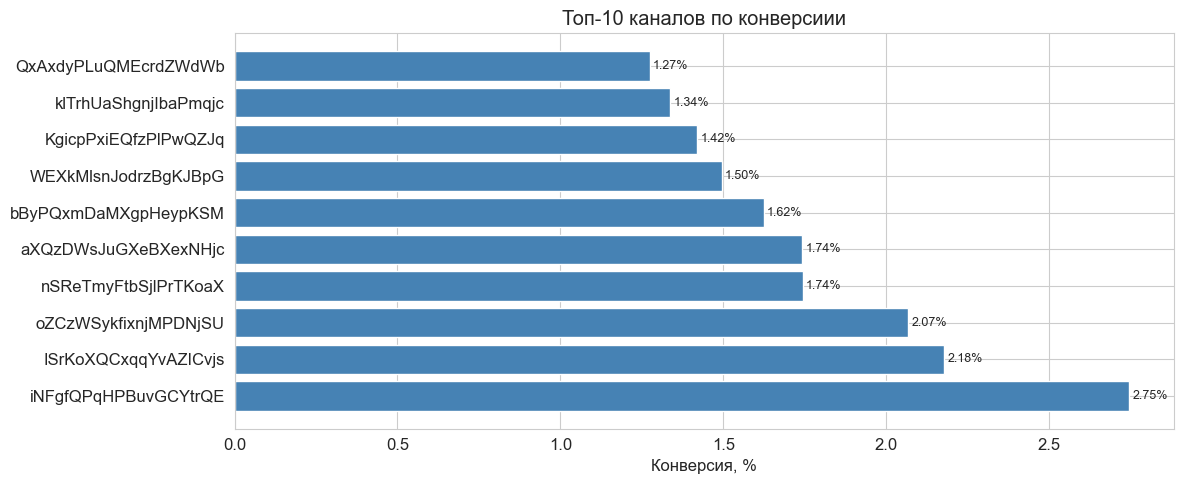


Статистика по каналам:
                      sessions  conversions  conv_rate
utm_source                                            
iNFgfQPqHPBuvGCYtrQE      3532           97   2.746319
ISrKoXQCxqqYvAZICvjs      8633          188   2.177690
oZCzWSykfixnjMPDNjSU      3143           65   2.068088
nSReTmyFtbSjlPrTKoaX      7285          127   1.743308
aXQzDWsJuGXeBXexNHjc     31152          543   1.743066
bByPQxmDaMXgpHeypKSM    102287         1662   1.624840
WEXkMlsnJodrzBgKJBpG      1003           15   1.495513
KgicpPxiEQfzPlPwQZJq      1761           25   1.419648
klTrhUaShgnjIbaPmqjc      1197           16   1.336675
QxAxdyPLuQMEcrdZWdWb     51415          655   1.273947


In [6]:
# Топ-10каналов привлечения по конверсии
source_stats = (
    df.groupby('utm_source')
    .agg(sessions=('target', 'count'), conversions=('target', 'sum'))
    .assign(conv_rate=lambda x: x['conversions'] / x['sessions'] * 100)
    .query('sessions >= 1000')
    .sort_values('conv_rate', ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(source_stats.index, source_stats['conv_rate'], color='steelblue')
ax.set_title('Топ-10 каналов по конверсиии')
ax.set_xlabel('Конверсия, %')
for bar, val in zip(bars, source_stats['conv_rate']):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print('\nСтатистика по каналам:')
print(source_stats.to_string())

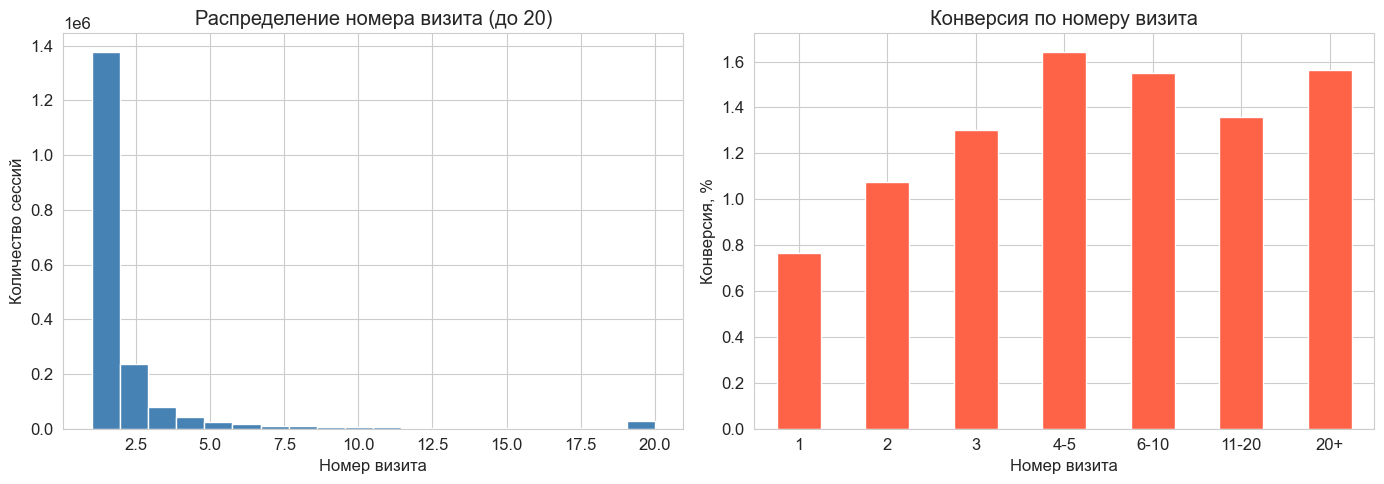


Вывод: пользователи с повторными визитами конвертируют лучше


In [7]:
# Распределение visit_number(порядковый номер визита клиента)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['visit_number'].clip(upper=20).hist(bins=20, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Распределение номера визита (до 20)')
axes[0].set_xlabel('Номер визита')
axes[0].set_ylabel('Количество сессий')

visit_conv = (
    df.assign(visit_bucket=pd.cut(df['visit_number'], bins=[0,1,2,3,5,10,20,1000],
                                   labels=['1','2','3','4-5','6-10','11-20','20+']))
    .groupby('visit_bucket', observed=True)['target']
    .mean() * 100
)
visit_conv.plot(kind='bar', ax=axes[1], color='tomato')
axes[1].set_title('Конверсия по номеру визита')
axes[1].set_xlabel('Номер визита')
axes[1].set_ylabel('Конверсия, %')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print('\nВывод: пользователи с повторными визитами конвертируют лучше')

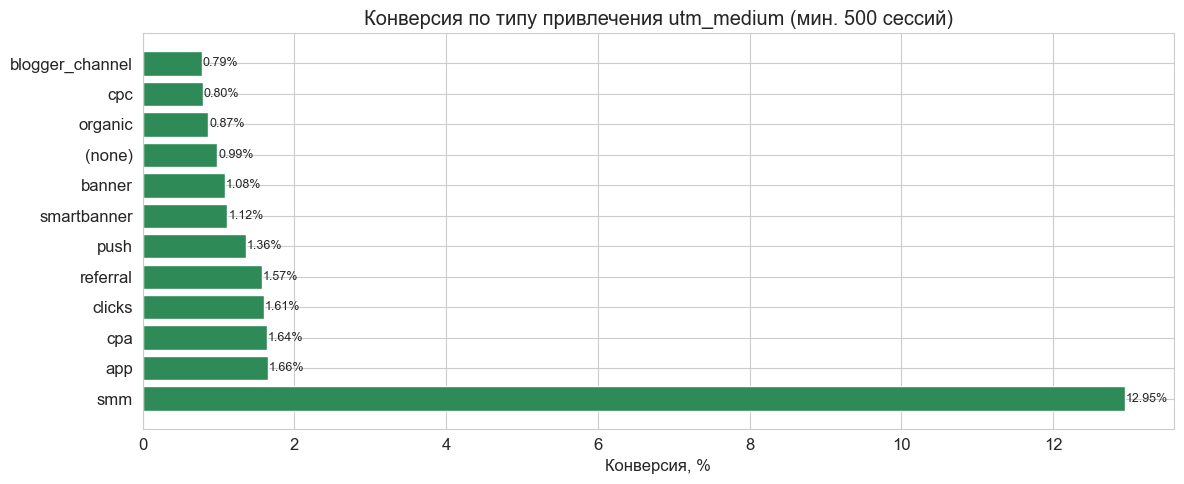

In [8]:
# Конверсия по utm_medium
medium_stats = (
    df.groupby('utm_medium')
    .agg(sessions=('target', 'count'), conversions=('target', 'sum'))
    .assign(conv_rate=lambda x: x['conversions'] / x['sessions'] * 100)
    .query('sessions >= 500')
    .sort_values('conv_rate', ascending=False)
    .head(12)
)
fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(medium_stats.index, medium_stats['conv_rate'], color='seagreen')
ax.set_title('Конверсия по типу привлечения utm_medium (мин. 500 сессий)')
ax.set_xlabel('Конверсия, %')
for bar, val in zip(bars, medium_stats['conv_rate']):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

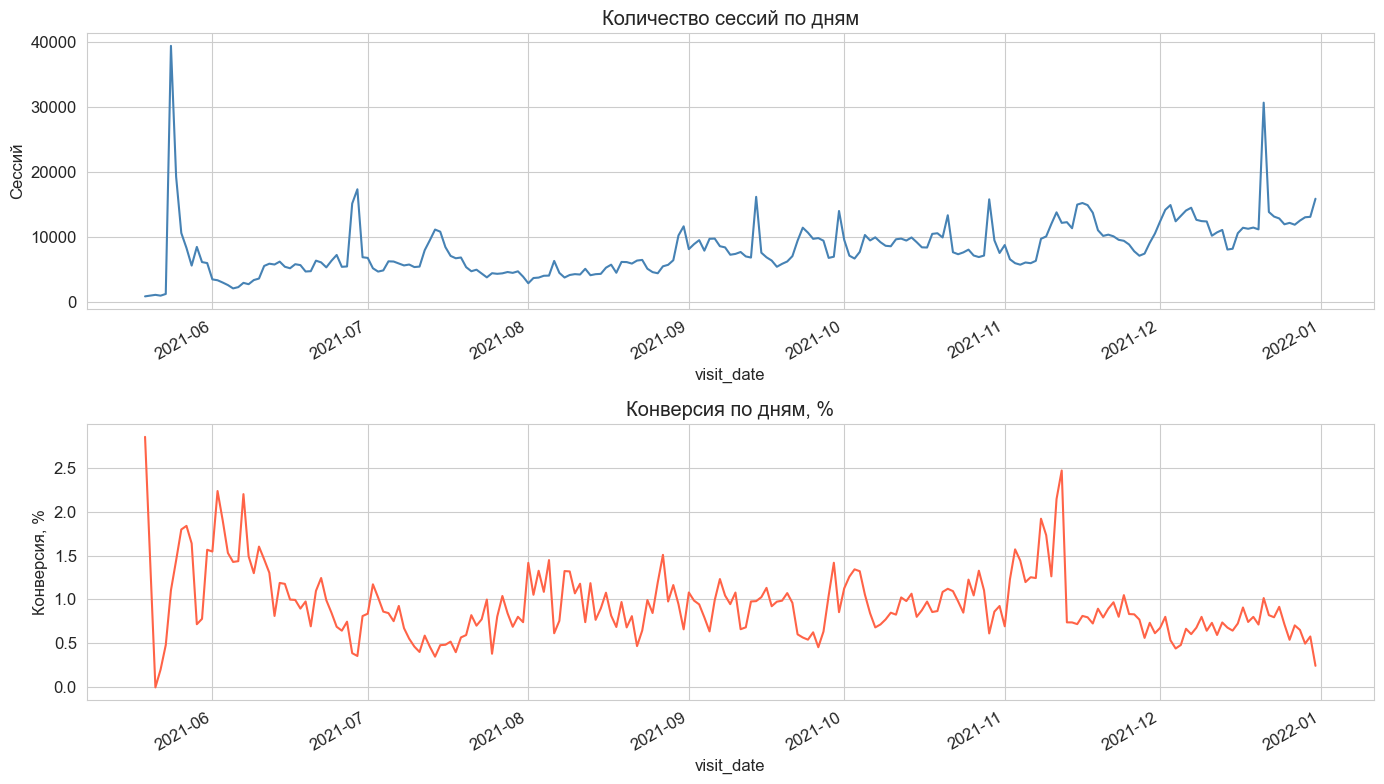

In [9]:
# Динамика сессий и конверсий по датам
daily = (
    df.groupby('visit_date')
    .agg(sessions=('target', 'count'), conversions=('target', 'sum'))
    .assign(conv_rate=lambda x: x['conversions'] / x['sessions'] * 100)
)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

daily['sessions'].plot(ax=axes[0], color='steelblue')
axes[0].set_title('Количество сессий по дням')
axes[0].set_ylabel('Сессий')

daily['conv_rate'].plot(ax=axes[1], color='tomato')
axes[1].set_title('Конверсия по дням, %')
axes[1].set_ylabel('Конверсия, %')

plt.tight_layout()
plt.show()

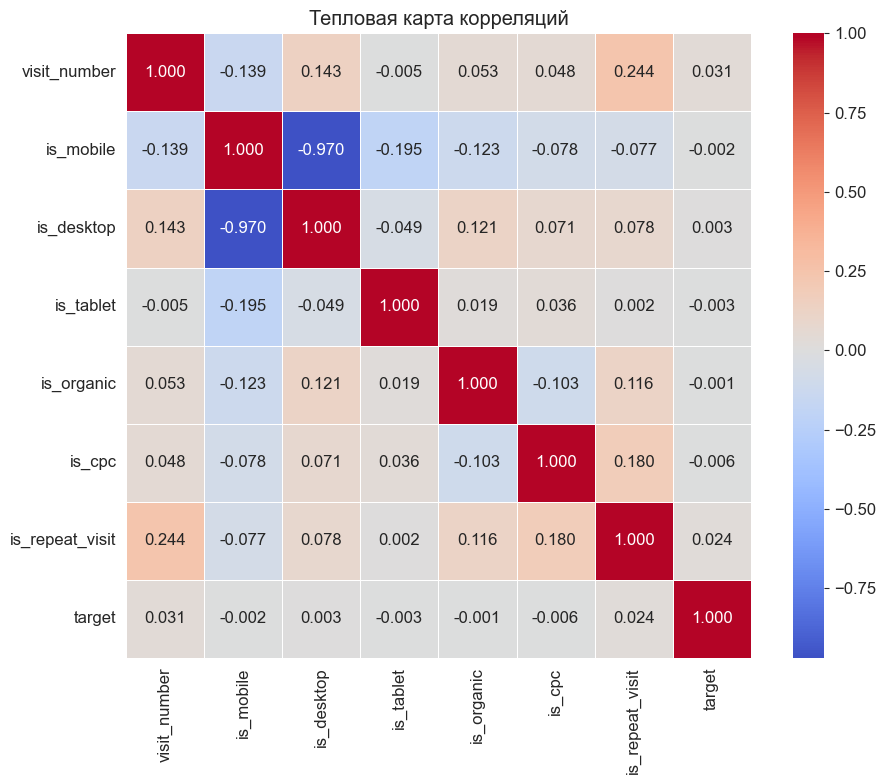


Корреляции с целевой переменной:
target             1.000000
visit_number       0.030947
is_repeat_visit    0.024003
is_desktop         0.003004
is_organic        -0.000620
is_mobile         -0.002309
is_tablet         -0.002630
is_cpc            -0.005845


In [10]:
# Тепловая карта корреляций (числовые признаки)
# Создаём числовые признаки из категориальных для корреляции
df_corr = df.copy()
df_corr['is_mobile'] = (df_corr['device_category'] == 'mobile').astype(int)
df_corr['is_desktop'] = (df_corr['device_category'] == 'desktop').astype(int)
df_corr['is_tablet'] = (df_corr['device_category'] == 'tablet').astype(int)
df_corr['is_organic'] = df_corr['utm_medium'].str.contains('organic', na=False).astype(int)
df_corr['is_cpc'] = df_corr['utm_medium'].str.contains('cpc', na=False).astype(int)
df_corr['is_repeat_visit'] = (df_corr['visit_number'] > 1).astype(int)

num_cols = ['visit_number', 'is_mobile', 'is_desktop', 'is_tablet',
            'is_organic', 'is_cpc', 'is_repeat_visit', 'target']

corr = df_corr[num_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            ax=ax, square=True, linewidths=0.5)
ax.set_title('Тепловая карта корреляций')
plt.tight_layout()
plt.show()

print('\nКорреляции с целевой переменной:')
print(corr['target'].sort_values(ascending=False).to_string())

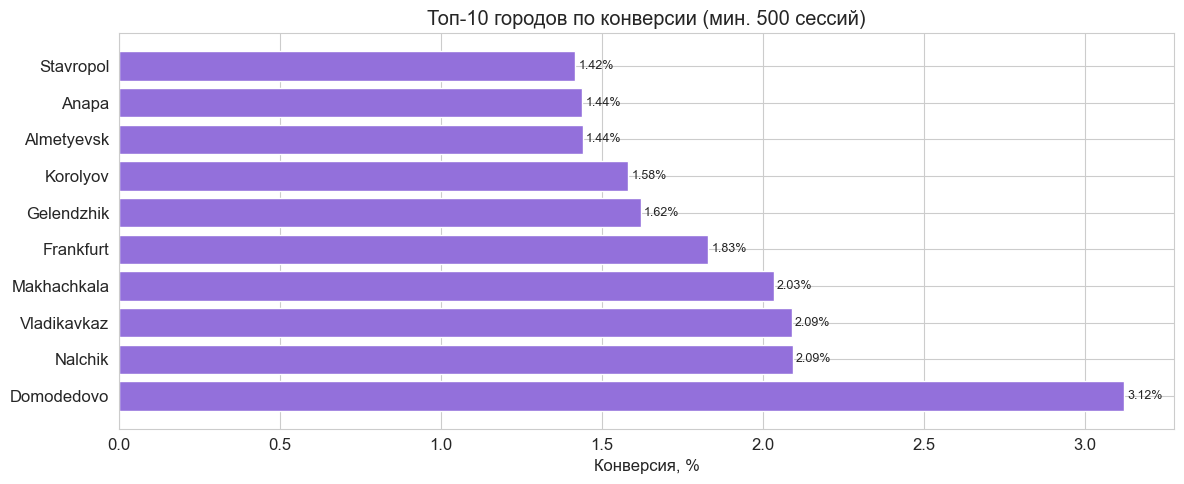

In [11]:
# Топ-10 городов по конверсии
city_stats = (
    df.groupby('geo_city')
    .agg(sessions=('target', 'count'), conversions=('target', 'sum'))
    .assign(conv_rate=lambda x: x['conversions'] / x['sessions'] * 100)
    .query('sessions >= 500')
    .sort_values('conv_rate', ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(city_stats.index, city_stats['conv_rate'], color='mediumpurple')
ax.set_title('Топ-10 городов по конверсии (мин. 500 сессий)')
ax.set_xlabel('Конверсия, %')
for bar, val in zip(bars, city_stats['conv_rate']):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

In [12]:
# Сохраняем очищенный датасет
CLEAN_PATH = r'C:\Users\Никита\Skillfactory\Project workshop (hackathon)\df_clean.csv'
df.to_csv(CLEAN_PATH, index=False)